In [ ]:
from matplotlib import figure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
from xgboost import XGBRegressor
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

warnings.filterwarnings("ignore")

df = pd.read_excel('../dados/Dados_TCC.xlsx', parse_dates=['Date'], index_col='Date')

# Baixa a cotação histórica do Dólar (BRL=X) respeitando o período do seu dataframe
print("Baixando cotação do Dólar...")
dolar_data = yf.download('BRL=X', start=df.index.min(), end=df.index.max())

# Adiciona a coluna de fechamento (Close) do dólar ao nosso DataFrame original
df['Dolar'] = dolar_data['Close']

# O mercado financeiro não abre aos finais de semana, então gerarão valores vazios (NaN).
# O método 'ffill' (forward fill) repete o valor de sexta-feira para o sábado e domingo.
df['Dolar'] = df['Dolar'].ffill()

# Remove qualquer linha inicial que ainda tenha ficado vazia
df = df.dropna()

colunas_para_normalizar = ['Etanol_Preco', 'Preco_Brent_USD', 'Dolar']

# Divisão Treino e Teste (80/20)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Treino: {len(train)} dias | Teste: {len(test)} dias")

Baixando cotação do Dólar...


[*********************100%***********************]  1 of 1 completed

Treino: 2398 dias | Teste: 600 dias


In [3]:
print("--- Treinando ---")

# =========================================================
# TRANSFORMAÇÃO FINANCEIRA (pct_change)
# =========================================================
# Vamos calcular a variação percentual diária de todas as variáveis
df['Etanol_Retorno'] = df['Etanol_Preco'].pct_change()
df['Dolar_Retorno'] = df['Dolar'].pct_change()
df['Brent_Retorno'] = df['Preco_Brent_USD'].pct_change()

# Remover a primeira linha que ficou vazia (NaN) por causa do cálculo de variação
df_model = df.dropna(subset=['Etanol_Retorno', 'Dolar_Retorno', 'Brent_Retorno']).copy()

# =========================================================
# CRIANDO OS LAGS (AGORA USANDO OS RETORNOS)
# =========================================================
def create_multivariate_lags(data, cols_to_lag, lags=5):
    df_lagged = data.copy()
    for col in cols_to_lag:
        for i in range(1, lags + 1):
            df_lagged[f'{col}_lag_{i}'] = df_lagged[col].shift(i)
    return df_lagged.dropna()

df_rf = create_multivariate_lags(df, cols_to_lag=['Etanol_Preco', 'Dolar', 'Preco_Brent_USD'], lags=10)

# Aplicando os Lags APENAS nas colunas de retorno
df_rf = create_multivariate_lags(df_model, cols_to_lag=['Etanol_Retorno', 'Dolar_Retorno', 'Brent_Retorno'], lags=10)

# Refazendo a divisão respeitando o novo tamanho do dataframe
train_size = int(len(df_rf) * 0.8)
train_rf = df_rf.iloc[:train_size]
test_rf = df_rf.iloc[train_size:]

# CRÍTICO: O '.drop' agora remove as colunas do dia atual para evitar trapaça do modelo (Data Leakage)
# Coloque aqui todas as colunas que NÃO são do passado (lags) ou que sejam de texto
colunas_para_remover = [
    'Etanol_Preco', 'Dolar', 'Preco_Brent_USD', 'Status_Periodo', # Remove os preços absolutos originais
    'Etanol_Retorno', 'Dolar_Retorno', 'Brent_Retorno'            # Remove o "gabarito" do dia atual
]

# 1. Separando as Pistas (X) e ignorando as colunas atuais
X_train_rf = train_rf.drop(columns=colunas_para_remover, errors='ignore')
X_test_rf = test_rf.drop(columns=colunas_para_remover, errors='ignore')

# 2. Separando o Alvo (y) - A resposta que queremos prever
y_train_rf = train_rf['Etanol_Retorno']
y_test_limpo = test_rf['Etanol_Retorno']

# =========================================================
# TRAVA DE SEGURANÇA: ALINHAMENTO DE COLUNAS
# =========================================================
# Garante que o Teste tenha as exatas mesmas colunas do Treino
colunas_faltantes = set(X_train_rf.columns) - set(X_test_rf.columns)
for col in colunas_faltantes:
    X_test_rf[col] = 0
X_test_rf = X_test_rf[X_train_rf.columns]

print(f" -> Colunas no Treino: {X_train_rf.shape[1]}")
print(f" -> Colunas no Teste: {X_test_rf.shape[1]}")

--- Treinando ---
 -> Colunas no Treino: 30
 -> Colunas no Teste: 30


In [8]:
print("\n--- Treinando XGBoost ---")
print("1. Iniciando o Grid Search para o XGBoost... (Aguarde)")

# =========================================================
# XGBOOST E GRID SEARCH
# =========================================================

# 1. Definir o "Cardápio" de Parâmetros (Grid)
param_grid = {
    'n_estimators': [100, 500],             # Reduzido para agilizar o teste
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'reg_alpha': [0, 0.1, 1.0],
    'reg_lambda': [1.0, 1.5, 5.0]
}

# 2. Divisão de Série Temporal
tscv = TimeSeriesSplit(n_splits=3)

# 3. Instanciar o modelo base para o Grid Search (SEM early stopping aqui)
xgb_base = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

# 4. Configurar e rodar o Grid Search
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

# Treinamos sem o eval_set
grid_search.fit(X_train_rf, y_train_rf)

# 5. Capturar os Melhores Parâmetros
melhores_parametros = grid_search.best_params_

print("\n" + "="*50)
print("🏆 PARÂMETROS ENCONTRADOS")
print("="*50)
for parametro, valor in melhores_parametros.items():
    print(f" - {parametro}: {valor}")

print("\n2. Treinando o modelo final com Early Stopping...")

# 6. Criar o modelo final usando os melhores parâmetros + Early Stopping
melhor_xgb = XGBRegressor(
    **melhores_parametros, # Desempacota os melhores parâmetros automaticamente
    early_stopping_rounds=20,
    random_state=42,
    objective='reg:squarederror'
)

# 7. Treinar o modelo final com o eval_set correto
melhor_xgb.fit(
    X_train_rf,
    y_train_rf,
    eval_set=[(X_test_rf, y_test_limpo)],
    verbose=False
)

print(f"\nO treinamento final parou na árvore número: {melhor_xgb.best_iteration}")
print("="*50)

# # 8. Fazendo a previsão
# xgb_pred = pd.Series(melhor_xgb.predict(X_test_rf), index=X_test_rf.index)

# Fazendo a previsão das Variações
xgb_pred_retornos = pd.Series(melhor_xgb.predict(X_test_rf), index=X_test_rf.index)


--- Treinando XGBoost ---
1. Iniciando o Grid Search para o XGBoost... (Aguarde)
Fitting 3 folds for each of 162 candidates, totalling 486 fits

🏆 PARÂMETROS ENCONTRADOS
 - learning_rate: 0.05
 - max_depth: 3
 - n_estimators: 100
 - reg_alpha: 0
 - reg_lambda: 1.0

2. Treinando o modelo final com Early Stopping...

O treinamento final parou na árvore número: 4


Gerando gráfico de Feature Importance...


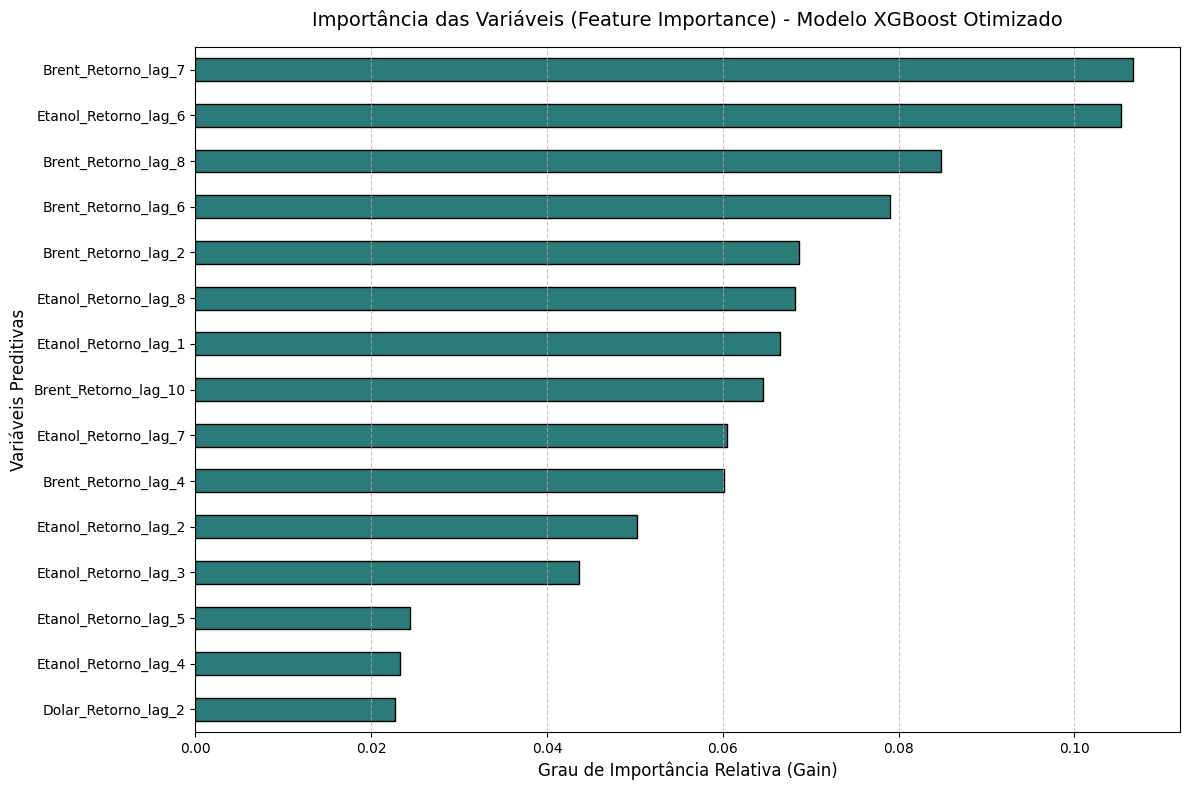

In [9]:
print("Gerando gráfico de Feature Importance...")

# 1. Extraindo as importâncias do modelo otimizado
importancias = melhor_xgb.feature_importances_

# 2. Resgatando os nomes das colunas que foram usadas no treino
nomes_variaveis = X_train_rf.columns

# 3. Criando uma série do Pandas para alinhar o nome com o valor
tabela_importancia = pd.Series(importancias, index=nomes_variaveis)

# 4. Ordenando os valores (do menor para o maior para o gráfico horizontal)
# Vamos pegar apenas as 15 variáveis mais importantes para não poluir o gráfico
top_variaveis = tabela_importancia.nlargest(15).sort_values(ascending=True)

# 5. Plotando com estética acadêmica
plt.figure(figsize=(12, 8))
top_variaveis.plot(kind='barh', color='#2b7b79', edgecolor='black')

plt.title('Importância das Variáveis (Feature Importance) - Modelo XGBoost Otimizado', fontsize=14, pad=15)
plt.xlabel('Grau de Importância Relativa (Gain)', fontsize=12)
plt.ylabel('Variáveis Preditivas', fontsize=12)

# Adicionando uma grade sutil apenas no eixo X para facilitar a leitura
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Gerando gráfico de previsões (Retornos)...


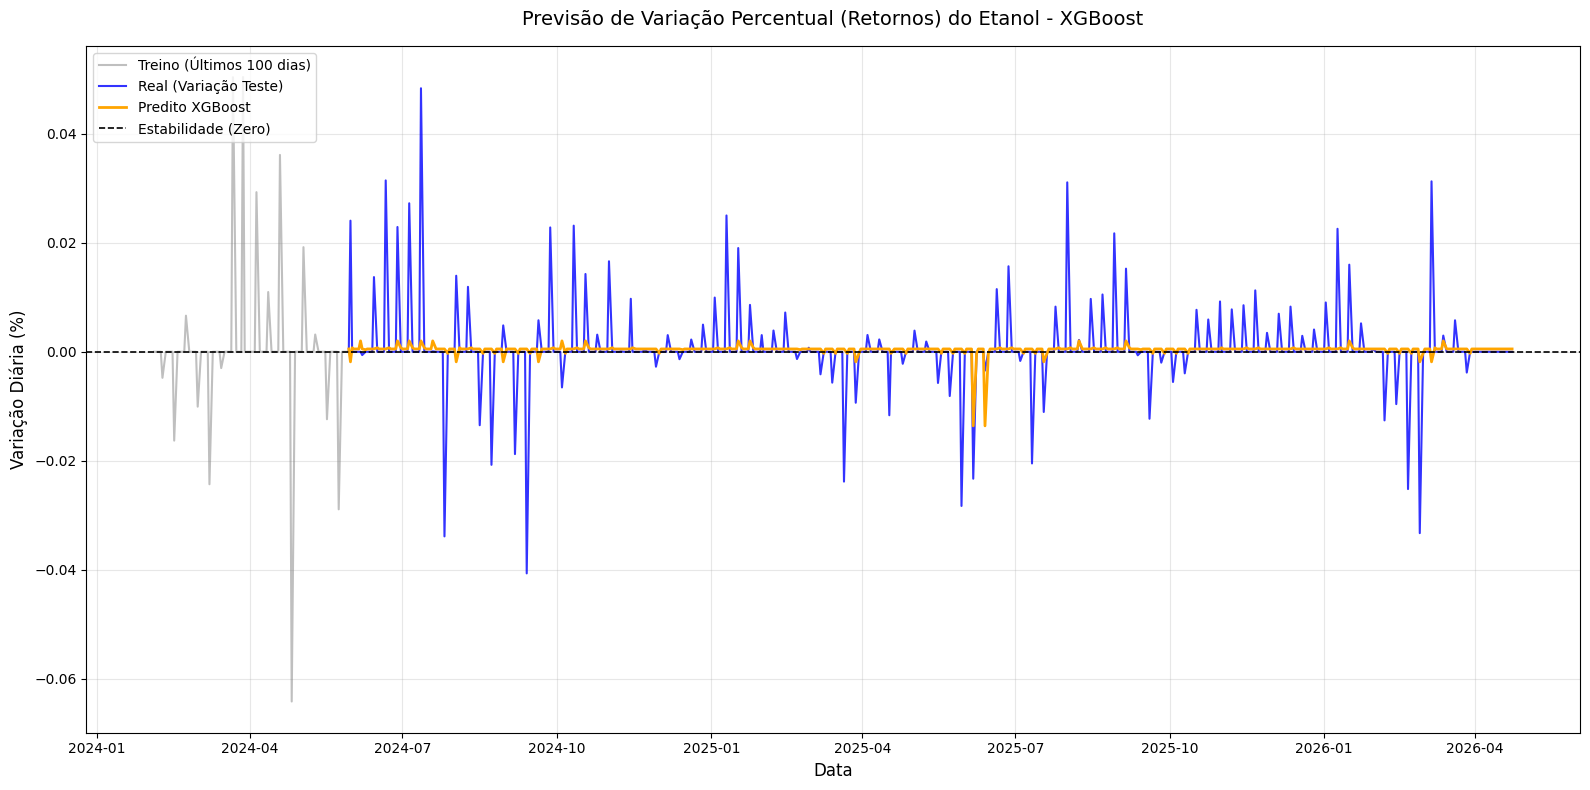


📊 DESEMPENHO DO MODELO (ESCALA PERCENTUAL)
RMSE: 0.006006 (Penaliza erros grandes na variação)
MAE:  0.002223 (Erro médio absoluto na variação)
Nota: Um erro de 0.01 equivale a errar a variação em 1 ponto percentual.


In [10]:
print("Gerando gráfico de previsões (Retornos)...")

# ==========================================
# Plotando o Gráfico
# ==========================================
# Ajustei o tamanho para 16x8, que costuma caber perfeitamente na página A4 de um TCC
plt.figure(figsize=(16, 8))

# Plotando os últimos 100 dias de treino para dar contexto (usando a coluna 'Etanol_Retorno')
plt.plot(train_rf.index[-100:], train_rf['Etanol_Retorno'][-100:], label='Treino (Últimos 100 dias)', color='gray', alpha=0.5)

# Plotando a variação real do teste
# Lembre-se: no último código guardamos a variação real do teste na variável y_test_limpo
plt.plot(X_test_rf.index, y_test_limpo, label='Real (Variação Teste)', color='blue', alpha=0.8)

# Plotando a predição do XGBoost
plt.plot(xgb_pred_retornos.index, xgb_pred_retornos, label='Predito XGBoost', color='orange', linewidth=2)

# Linha do Zero (Fundamental para gráficos de retorno)
plt.axhline(0, color='black', linewidth=1.2, linestyle='--', label='Estabilidade (Zero)')

# Estética Acadêmica
plt.title('Previsão de Variação Percentual (Retornos) do Etanol - XGBoost', fontsize=14, pad=15)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Variação Diária (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# Placar de Métricas (Agora em Variação Percentual)
# ==========================================
rmse_xgb = np.sqrt(mean_squared_error(y_test_limpo, xgb_pred_retornos))
mae_xgb = mean_absolute_error(y_test_limpo, xgb_pred_retornos)

print("\n" + "="*50)
print("📊 DESEMPENHO DO MODELO (ESCALA PERCENTUAL)")
print("="*50)
# Usando 4 ou 6 casas decimais, pois os valores de retorno são pequenos (ex: 0.0150)
print(f"RMSE: {rmse_xgb:.6f} (Penaliza erros grandes na variação)")
print(f"MAE:  {mae_xgb:.6f} (Erro médio absoluto na variação)")
print("="*50)
print("Nota: Um erro de 0.01 equivale a errar a variação em 1 ponto percentual.")

In [12]:
print("\n" + "="*50)
print("🏆 PLACAR DE AVALIAÇÃO - XGBOOST (VARIAÇÃO PERCENTUAL)")
print("="*50)

# 1. Alinhamento com as variáveis de Retorno geradas no bloco anterior
y_true = y_test_limpo
y_pred = xgb_pred_retornos

# 2. Cálculos das Métricas
# Como a base está em decimais (ex: 0.02 = 2%), multiplicamos por 100
# para que a leitura fique mais intuitiva (em pontos percentuais).
rmse = np.sqrt(mean_squared_error(y_true, y_pred)) * 100
mae = mean_absolute_error(y_true, y_pred) * 100

# 3. Exibição dos Resultados
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} pontos percentuais")
print(f"MAE  (Mean Absolute Error):     {mae:.4f} pontos percentuais")

# Cálculo do MAPE com trava de segurança
# Atenção: O MAPE é perigoso em séries de retorno porque se a variação real de um dia
# for zero (ou quase zero), a divisão por zero fará a métrica explodir ao infinito.
try:
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    print(f"MAPE (Mean Abs. Percent Error): {mape:.2f}%")
except Exception as e:
    print("MAPE: Indisponível (Variação real continha valores exatos de 0%)")

print("="*50)
print("Nota explicativa para a Monografia:")
print("Um MAE de 1.50 significa que o modelo erra a variação diária em 1,5 ponto percentual na média.")
print("="*50)


🏆 PLACAR DE AVALIAÇÃO - XGBOOST (VARIAÇÃO PERCENTUAL)
RMSE (Root Mean Squared Error): 0.6006 pontos percentuais
MAE  (Mean Absolute Error):     0.2223 pontos percentuais
MAPE (Mean Abs. Percent Error): 195980757004349.78%
Nota explicativa para a Monografia:
Um MAE de 1.50 significa que o modelo erra a variação diária em 1,5 ponto percentual na média.
